In [1]:
%pip install -U huggingface_hub

   ---------------------------------------- 0.0/838.0 kB ? eta -:--:--
   ---------------------------------------- 838.0/838.0 kB 9.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ----------------------------------- ---- 3.4/3.8 MB 16.7 MB/s eta 0:00:01
   ---------------------------------------- 3.8/3.8 MB 14.2 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.13.2
    Uninstalling typing_extensions-4.13.2:
      Successfully uninstalled typing_extensions-4.13.2
  Attempting uninstall: idna
    Found existing installation: idna 3.7
    Uninstalling idna-3.7:
      Successfully uninstalled idna-3.7
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.12.0 requires flatbuffers>=2.0, which is not installed.
tensorflow-intel 2.12.0 requires jax>=0.3.15, which is not installed.
tensorflow-intel 2.12.0 requires keras<2.13,>=2.12.0, which is not installed.
tensorflow-intel 2.12.0 requires libclang>=13.0.0, which is not installed.
tensorflow-intel 2.12.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, which is not installed.
tensorflow-intel 2.12.0 requires tensorflow-estimator<2.13,>=2.12.0, which is not installed.
tensorflow-intel 2.12.0 requires tensorflow-io-gcs-filesystem>=0.23.1; platform_machine != "arm64" or platform_system != "Darwin", which is not installed.
tensorflow-intel 2.12.0 requires termcolor>=1.1.0, which is not installed.
tensorflow-intel 2.12.0 requires wrapt<1.15,>=1.11.0, which is no

In [2]:
from huggingface_hub import snapshot_download
from pathlib import Path

dossier = Path(r"C:\Users\decroux paul\Documents\info\OCR_deux\GLM-OCR")

snapshot_download(
    repo_id="zai-org/GLM-OCR",
    local_dir=str(dossier)
)

print("Modèle téléchargé :", dossier)

c:\Users\decroux paul\anaconda3\envs\bourse\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 12 files: 100%|██████████| 12/12 [12:50<00:00, 64.19s/it] 

Modèle téléchargé : C:\Users\decroux paul\Documents\info\OCR_deux\GLM-OCR


In [3]:
from pathlib import Path

model_dir = Path(r"C:\Users\decroux paul\Documents\info\OCR_deux\GLM-OCR")
source = model_dir / "model.safetensors"

chunk_size = 1024 * 1024 * 1024  # 1 Gio

with source.open("rb") as fichier:
    i = 0
    while True:
        data = fichier.read(chunk_size)
        if not data:
            break

        destination = model_dir / f"model.safetensors.part{i:03d}"
        destination.write_bytes(data)
        print(f"Créé : {destination.name}")
        i += 1

print("Découpage terminé !")

Créé : model.safetensors.part000
Créé : model.safetensors.part001
Créé : model.safetensors.part002
Découpage terminé !


In [1]:
from pathlib import Path
import shutil

model_dir = Path(r"C:\Users\decroux paul\Documents\info\OCR_deux\GLM-OCR")

parties = sorted(model_dir.glob("model.safetensors.part*"))
destination = model_dir / "model_reconstruit.safetensors"

assert len(parties) == 3, f"3 morceaux attendus, {len(parties)} trouvés"

with destination.open("wb") as sortie:
    for partie in parties:
        print(f"Assemblage de {partie.name}...")
        with partie.open("rb") as entree:
            shutil.copyfileobj(entree, sortie, length=8 * 1024 * 1024)

print("Reconstruction terminée !")
print(f"Taille : {destination.stat().st_size / 1024**3:.2f} Gio")

Assemblage de model.safetensors.part000...
Assemblage de model.safetensors.part001...
Assemblage de model.safetensors.part002...
Reconstruction terminée !
Taille : 2.47 Gio


In [2]:
import hashlib

def sha256_fichier(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for bloc in iter(lambda: f.read(8 * 1024 * 1024), b""):
            h.update(bloc)

    return h.hexdigest()


original = model_dir / "model.safetensors"

hash_original = sha256_fichier(original)
hash_reconstruit = sha256_fichier(destination)

print("Original     :", hash_original)
print("Reconstruit  :", hash_reconstruit)

assert hash_original == hash_reconstruit, "ERREUR : fichiers différents !"

print("✅ Reconstruction parfaite : fichiers strictement identiques.")

Original     : a16eb0de98d199293371c560f95f83130d2a2c9612449df16839f08ff9498815
Reconstruit  : a16eb0de98d199293371c560f95f83130d2a2c9612449df16839f08ff9498815
✅ Reconstruction parfaite : fichiers strictement identiques.


In [3]:
import torch
import torchvision
import transformers

print("PyTorch :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("Transformers :", transformers.__version__)

c:\Users\decroux paul\anaconda3\envs\bourse\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch : 2.14.1+cpu
Torchvision : 0.29.1+cpu
Transformers : 5.19.0


In [4]:
import os
import shutil
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

test_dir = model_dir.parent / "GLM-OCR-test"
test_dir.mkdir(exist_ok=True)

# Copier les petits fichiers de configuration
for fichier in model_dir.iterdir():
    if fichier.is_file() and fichier.name not in (
        "model.safetensors",
        "model_reconstruit.safetensors"
    ) and not ".part" in fichier.name:
        shutil.copy2(fichier, test_dir / fichier.name)

# Créer un lien vers le modèle reconstruit, sans le recopier
poids_test = test_dir / "model.safetensors"

if not poids_test.exists():
    os.link(destination, poids_test)

processor = AutoProcessor.from_pretrained(
    str(test_dir),
    local_files_only=True
)

model = AutoModelForImageTextToText.from_pretrained(
    str(test_dir),
    dtype=torch.float32,
    device_map="cpu",
    local_files_only=True
)

model.eval()

print("✅ GLM-OCR reconstruit et chargé avec succès !")

Loading weights: 100%|██████████| 510/510 [00:07<00:00, 63.98it/s]


✅ GLM-OCR reconstruit et chargé avec succès !


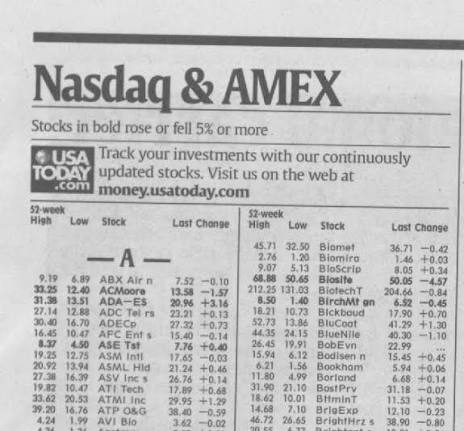


========== RÉSULTAT OCR ==========

Nasdaq & AMEX

Stocks in bold rose or fell 5% or more

Track your investments with our continuously updated stocks. Visit us on the web at money.usatoday.com

52-week High Low Stock Last Change 52-week High Low Stock Last Change
9.19 6.89 ABX Air n 7.52 -0.10 45.71 32.50 Blomet 36.71 -0.42
10.58 12.40 ACMoore 13.58 -1.57 2.76 1.20 Birota 40.03 -0.03
31.38 12.91 ADA-ES 20.96 -1.26 9.07 5.13 Bioscript 8.05 +0.34
27.14 12.88 ADC Tel rs 23.21 +0.13 68.88 50.65 Biosite 50.05 -4.57
30.40 16.70 ADEcP 27.22 +0.73 52.73 13.86 BlucOat 41.29 +1.30
16.45 10.47 AFC Ent s 15.40 -0.14 44.35 24.15 BiueNile 40.30 -1.10
8.82 12.75 AM Intl 17.65 -0.03 15.94 6.12 Bodsen k 15.45 +0.45
19.25 12.75 AM Intl 17.65 -0.03 15.94 6.12 Bodsen k 15.45 +0.45
20.92 12.75 ASM Intl 17.65 -0.03 6.21 1.56 Bookham 5.94 +0.06
27.38 16.39 ASV Inc s 26.76 +0.14 11.80 4.99 Borland 6.68 +0.14
37.38 16.39 ASV Inc s 26.76 +0.14 11.80 4.99 Borland 6.68 +0.14
36.23 10.58 ATM Intl 18.62 10.01 Btm

In [5]:
import torch
from pathlib import Path
from PIL import Image
from IPython.display import display

image_path = Path(
    r"C:\Users\decroux paul\Documents\info\OCR_deux\GLM-OCR\test.jpg"
)

# Vérifier et afficher l'image
assert image_path.exists(), "Image introuvable !"

image = Image.open(image_path).convert("RGB")
display(image)

# Préparer la requête OCR
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Text Recognition:"}
        ]
    }
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt"
)

inputs = inputs.to("cpu")

# Exécuter GLM-OCR
model.eval()

with torch.inference_mode():
    outputs = model.generate(
        **inputs,
        max_new_tokens=2048,
        do_sample=False
    )

# Décoder uniquement la réponse générée
generated = outputs[0][inputs["input_ids"].shape[-1]:]

texte = processor.decode(
    generated,
    skip_special_tokens=True
)

print("\n========== RÉSULTAT OCR ==========\n")
print(texte)